# Self-consistent solution of the SYK equation using the Discrete Lehman Representation, with progressive cooling

This example is similar to the tutorial "Self-consistent solution of the SYK equation using the Discrete Lehmann Representation", but it reaches low temperatures by using the calculation for a larger temperature as an initial guess for the next lowest temperature. While this does not appear to be necessary for the SYK model solves using fixed point iteration with mixing, it can be required in more complicated settings, and it is useful to see how the solution using a DLR grid for one temperature can be interpolated to a DLR grid for a lower temperature. 

In [104]:
from triqs.gf import *
from triqs.gf.tools import *
from triqs.operators import *
from triqs.gf.block_gf import *
from triqs.gf.descriptors import Function
import h5
import numpy as np
from triqs.plot.mpl_interface import *
import matplotlib.pyplot as plt
import matplotlib as mpl
import json, sys, os

params = {
    "beta": 500.0,
    "mu": 0.0,
    "alpha" : 0.75,
    "w_max": 10.0,
    "dlr_err": 1e-12, 
    "J" : 1.0,
    "max_iter": 1000,
    "threshold": 1e-8,
}

gf_struct =[('up',1), ('dn',1)]
iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps = params["dlr_err"], symmetrize = True)
G_iw   = BlockGf(mesh=iw_mesh, gf_struct=gf_struct)
G_tau = make_gf_dlr_imtime(G_iw)
Sigma_iw = G_iw.copy()
Sigma_tau = make_gf_dlr_imtime(Sigma_iw)
betas = np.array([50.0, 100.0, 200.0, 500.0, 1000.0])  # Different beta values for testing

for i, beta in enumerate(betas):
    gf_struct =[('up',1), ('dn',1)]
    params["beta"] = beta
 
    iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps = params["dlr_err"], symmetrize = True)

    G_iw   = BlockGf(mesh=iw_mesh, gf_struct=gf_struct)
    G_tau = make_gf_dlr_imtime(G_iw)
    Sigma_iw = G_iw.copy()
    Sigma_tau = make_gf_dlr_imtime(Sigma_iw)
    if i == 0:
        G_iw << SemiCircular(1.0)
    if i > 1:
        tau = np.array([x.real for x in G_tau.mesh.values()], dtype=np.float64)
        old_tau = np.array([x.real for x in G_old.mesh.values()], dtype=np.float64)
        old_beta = np.max(old_tau)
        tau_prime = tau*old_beta/params["beta"]
        G_dlr = make_gf_dlr(G_old)
        for block, g in G_tau:
            g.data[:,0,0] = np.array([G_dlr["up"](t)[0,0] for t in tau_prime])
        G_iw << make_gf_dlr_imfreq(G_tau)

    G_tau << make_gf_dlr_imtime(G_iw)   # Initial guess in the imaginary time domain
    error = 1.0
    iter = 0

    while error > params["threshold"]:
        tau = np.array([x.real for x in G_tau.mesh.values()], dtype=np.float64) 
        for block, g in G_tau:
            G_dlr = make_gf_dlr(g)
            Sigma_tau[block].data[:,0,0] = np.array([G_dlr(t)[0,0]**2*G_dlr(params["beta"]-t)[0,0] for t in tau]) # Compute self-energy in imaginary time

        Sigma_iw << make_gf_dlr_imfreq(Sigma_tau)                                       # Transform self-energy to Matsubara frequency domain 

        for block, g in G_tau:
            G_iw[block] << inverse(iOmega_n - Sigma_iw[block])                          # Solve the Dyson equation to obtain Green's function
        G_old = G_tau.copy()
        G_tau << params["alpha"]*G_old + (1-params["alpha"])*make_gf_dlr_imtime(G_iw)   # Update Green's function via weighted fixed point iteration
        error = np.max(np.abs((G_tau["up"].data[:,0,0] - G_old["up"].data[:,0,0])))     # Compute absolute error
        iter += 1

        print("Iteration:", iter, "Error:", error)
        if iter > params["max_iter"]:
            print("Maximum number of iterations reached without convergence")
            break

Iteration: 1 Error: 0.08341268718616414
Iteration: 2 Error: 0.020624876522001262
Iteration: 3 Error: 0.008508362270219227
Iteration: 4 Error: 0.004128924998232253
Iteration: 5 Error: 0.002140514522045611
Iteration: 6 Error: 0.0011588001998710795
Iteration: 7 Error: 0.000641626565325959
Iteration: 8 Error: 0.0003685756237916671
Iteration: 9 Error: 0.00021545130661632106
Iteration: 10 Error: 0.00012725475457886493
Iteration: 11 Error: 7.583129203281302e-05
Iteration: 12 Error: 4.614611609254915e-05
Iteration: 13 Error: 2.8492743066987902e-05
Iteration: 14 Error: 1.772916584391604e-05
Iteration: 15 Error: 1.1111730505386497e-05
Iteration: 16 Error: 7.011361329800625e-06
Iteration: 17 Error: 4.492548279610986e-06
Iteration: 18 Error: 2.9235559191875815e-06
Iteration: 19 Error: 1.9132391210208155e-06
Iteration: 20 Error: 1.2584982634900044e-06
Iteration: 21 Error: 8.316886299097881e-07
Iteration: 22 Error: 5.519602330195106e-07
Iteration: 23 Error: 3.67725420280518e-07
Iteration: 24 Error: 

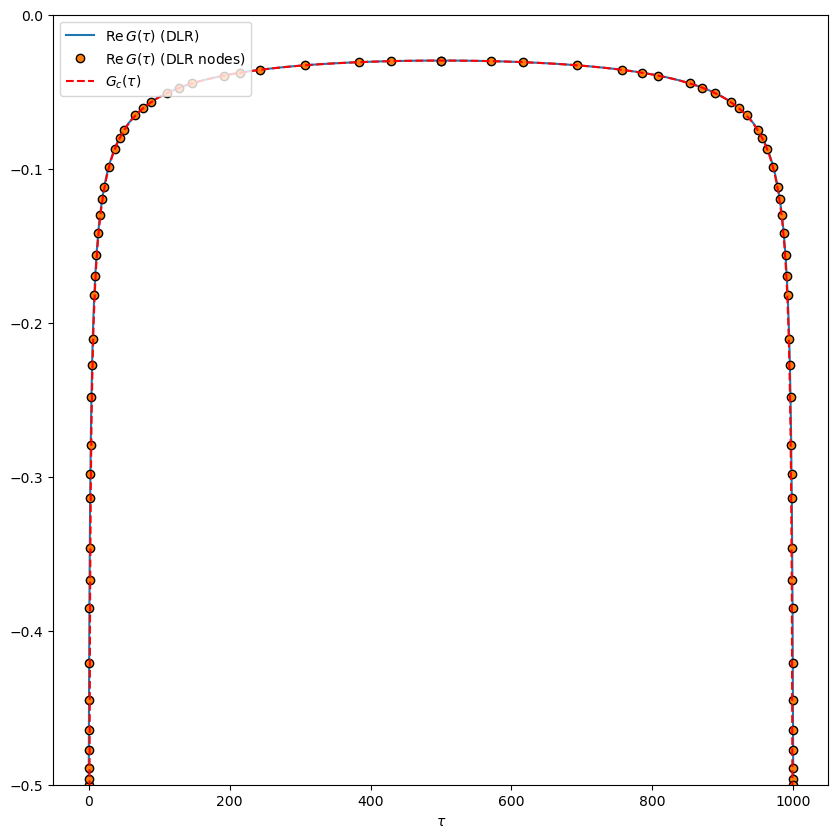

In [105]:
G_tau_dense = make_gf_imtime(G_tau["up"], n_tau=1000)                                                   # Obtain DLR expansion on dense imaginary time grid
t =  np.array([x.real for x in G_tau_dense.mesh.values()])[1:]                                          # Obtain dense grid
Gconformal = -np.pi**(1/4) / np.sqrt(2*params["beta"]) * 1/np.sqrt(np.sin(np.pi * t / params["beta"]))  # Conformal solution

plt.figure(figsize = (10,10))
oplot(G_tau_dense.real, label = r"$\mathrm{Re}\, G(\tau)$ (DLR)")
oplot(G_tau["up"].real, marker = "o", markeredgecolor = "black", label = r"$\mathrm{Re}\, G(\tau)$ (DLR nodes)")
plt.plot(t, Gconformal, label = r"$G_c(\tau)$", color = "red", linestyle = "dashed")
plt.ylim(-0.5,0)
plt.ylabel("")
plt.legend(loc="upper left")
plt.show()

### Exercise 2 

Next try repeating Tutorial 1 to converge the IPT equations for a given $\beta$ and $U$. Check how much quicker your calculations are compared to Tutorial 1. Then obtain a Padé approximation of the spectral function $A(\omega)$.


In [106]:

from triqs.gf import *
import numpy as np
from triqs.operators import *

class IPTSolver:
    def __init__(self, params):
        self.params = params
        # Matsubara frequency Green's functions
        iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G_iw = BlockGf(mesh=iw_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G0_iw = self.G_iw.copy() # self.G0 will be set by the user after initialization
        self.Sigma_iw = self.G_iw.copy()

        # Imaginary time
        tau_mesh = MeshDLRImTime(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G0_tau = BlockGf(mesh=tau_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G_tau = self.G0_tau.copy()
        self.Sigma_tau = self.G0_tau.copy()

    def solve(self):
        error = 1.0
        iter = 0

In [112]:
params = {
    "beta": 50.0,
    "mu": 0.0,
    "alpha" : 0.5,
    "w_max": 10.0,
    "dlr_err": 1e-8, 
    "U" : 3.0, # In the Mott state, U > 4, you run into trouble, but this is also why the IPT tutorial just stops at small iteration number. 
    "t" : 1.0,
    "max_iter": 1000,
    "threshold": 1e-8,
}

In [113]:
S = IPTSolver(params)
S.G_iw << SemiCircular(2*params["t"])


Green Function G composed of 2 blocks: 
 Greens Function G_up with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 
 Greens Function G_dn with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 

In [114]:
error = 1.0
iter = 0
while error > params["threshold"]:
    for block, g in S.G0_iw:
        g << inverse( iOmega_n - params["t"]**2 * S.G_iw[block] )
    S.G0_tau << make_gf_dlr_imtime(S.G0_iw)
    S.Sigma_tau << (params["U"]**2) * S.G0_tau * S.G0_tau * S.G0_tau
    S.Sigma_iw << make_gf_dlr_imfreq(S.Sigma_tau)
    G_old = S.G_iw.copy()
    S.G_iw << inverse(inverse(S.G0_iw) - S.Sigma_iw)
    S.G_iw << params["alpha"]*S.G_iw+ (1-params["alpha"])*G_old
    G_tau_old = S.G_tau.copy()
    S.G_tau << make_gf_dlr_imtime(S.G_iw)
    error = np.max(np.abs((S.G_tau["up"].data[:,0,0] - G_tau_old["up"].data[:,0,0])))     # Compute absolute error
    iter += 1

    print("Iteration:", iter, "Error:", error)
    if iter > params["max_iter"]:
        print("Maximum number of iterations reached without convergence")
        break

Iteration: 1 Error: 0.4994691601105864
Iteration: 2 Error: 0.013218442183916101
Iteration: 3 Error: 0.006275825531574575
Iteration: 4 Error: 0.002993884912959155
Iteration: 5 Error: 0.0014307653808706133
Iteration: 6 Error: 0.0006841141729723721
Iteration: 7 Error: 0.00032711102854793284
Iteration: 8 Error: 0.0001563808101129327
Iteration: 9 Error: 7.474213040459254e-05
Iteration: 10 Error: 3.571384048717263e-05
Iteration: 11 Error: 1.719079397405343e-05
Iteration: 12 Error: 8.315824688021056e-06
Iteration: 13 Error: 4.021901271578088e-06
Iteration: 14 Error: 1.9448479028350008e-06
Iteration: 15 Error: 9.403252946849072e-07
Iteration: 16 Error: 4.545876733930143e-07
Iteration: 17 Error: 2.197414414872867e-07
Iteration: 18 Error: 1.0621059087778661e-07
Iteration: 19 Error: 5.1332351869159965e-08
Iteration: 20 Error: 2.4807740583998594e-08
Iteration: 21 Error: 1.1988382841998657e-08
Iteration: 22 Error: 5.7931588970383554e-09


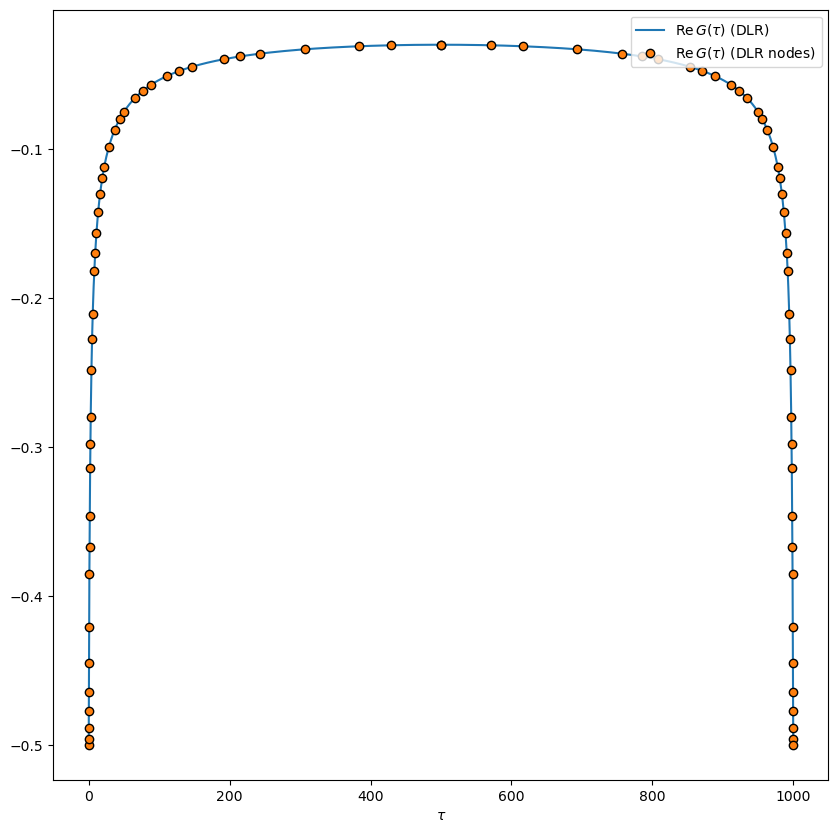

In [116]:
G_tau_dense = make_gf_imtime(G_tau["up"], n_tau=1000)   # Obtain DLR expansion on dense imaginary time grid

plt.figure(figsize = (10,10))
oplot(G_tau_dense.real, label = r"$\mathrm{Re}\, G(\tau)$ (DLR)")
oplot(G_tau["up"].real, marker = "o", markeredgecolor = "black", label = r"$\mathrm{Re}\, G(\tau)$ (DLR nodes)")
plt.ylabel("")
plt.legend(loc="upper right")
plt.show()

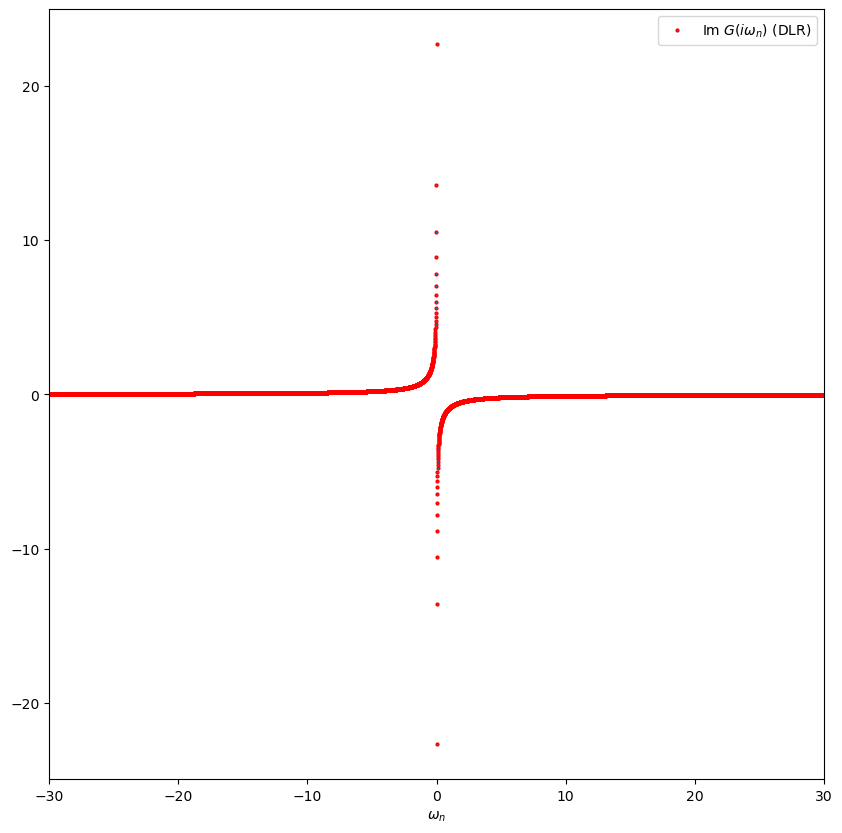

In [121]:
G_iw_dense = make_gf_imfreq(G_iw["up"], n_iw = 5000)    # Obtain DLR expansion on dense Matsubara frequency grid

plt.figure(figsize = (10,10))
oplot(G_iw_dense.imag, marker = "o", markeredgecolor = "red", markersize=2, linestyle="none", label = r"Im $G(i \omega_n)$ (DLR)")
plt.xlim(-30,30)
plt.ylabel("")
plt.show()

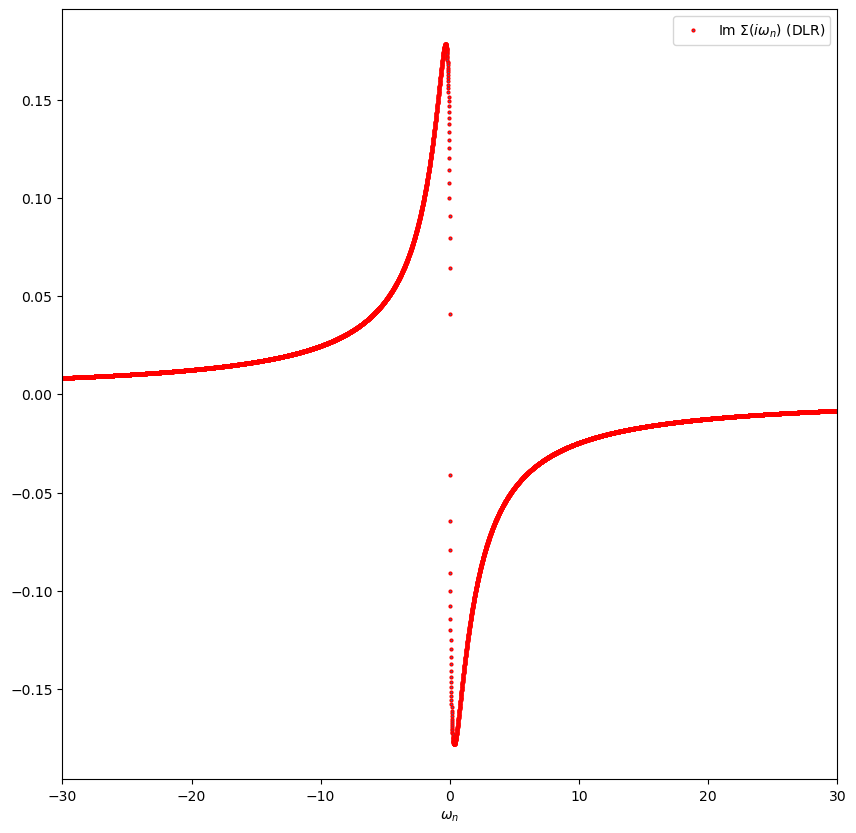

In [122]:
Sigma_iw_dense = make_gf_imfreq(Sigma_iw["up"], n_iw = 5000)    # Obtain DLR expansion of self-energy on dense Matsubara frequency grid

plt.figure(figsize = (10,10))
oplot(Sigma_iw_dense.imag, marker = "o", markeredgecolor = "red", markersize=2, linestyle="none", label = r"Im $\Sigma(i \omega_n)$ (DLR)")
plt.xlim(-30,30)
plt.ylabel("")
plt.show()

In [123]:
G_w = Gf(mesh=MeshReFreq(window = (-5.0,5.0), n_w=1000), target_shape=[1,1])
G_iw = make_gf_imfreq(S.G_iw["up"], n_iw = 2**14+3)
G_w.set_from_pade(G_iw, 100, 0.01)      # Pade analytic continuation

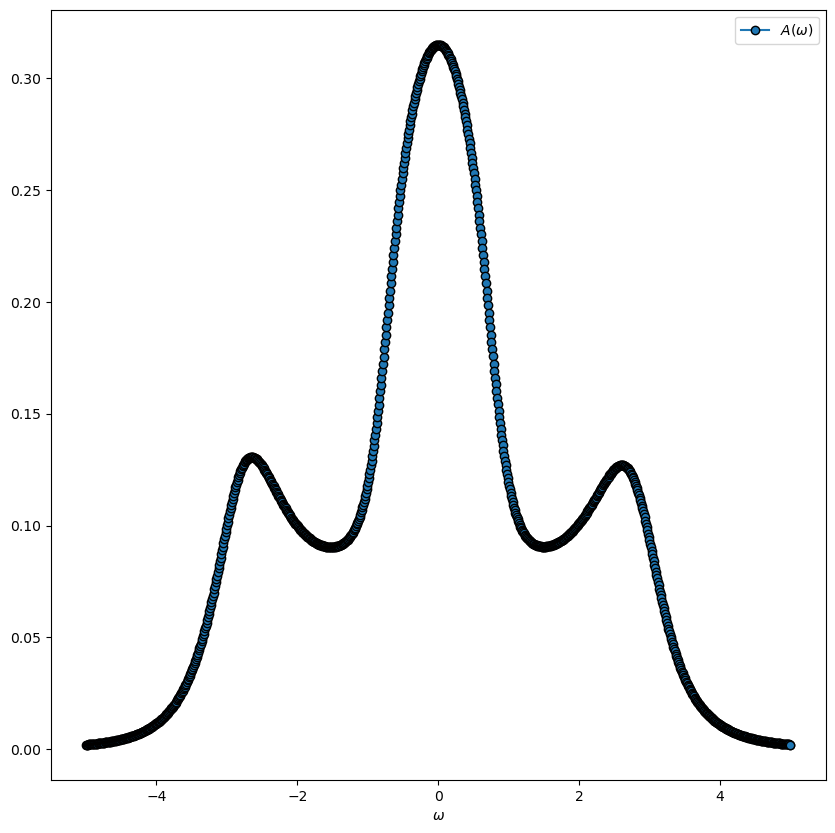

In [124]:
plt.figure(figsize = (10,10))
oplot(-np.imag(G_w)/np.pi, marker = "o", markeredgecolor = "black", label = r"$A(\omega)$")
plt.ylabel("")
plt.show()